# Project 1

In [ ]:
# Import modules
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
# Import data
customers = pd.read_csv("data/customers.csv")
transactions = pd.read_csv("data/transactions.csv")
sessions = pd.read_csv("data/web_sessions.csv")
campaigns = pd.read_csv("data/marketing_campaigns.csv")

### Specific questions

Q1. What is the average purchase value for customers from Spain?

In [9]:
# Merge transactions with customer data
merged = transactions.merge(customers, on="customer_id")

# Filter out for Spain
spain_df = merged[merged["country"] == "Spain"]

# Average purchase value
average_spain = spain_df["purchase_value"].mean()

# Display result
print(f"Average purchase value for customers from Spain: {average_spain:.2f}")

Average purchase value for customers from Spain: 75.63


Q2. What is the minimum purchase value for customers from Germany?

In [ ]:
# Filter out for Germany
germany_df = merged[merged["country"] == "Germany"]

# Minimum purchase value
min_germany = germany_df["purchase_value"].min()

# Display result
print(f"Minimum purchase value for customers from Germany: {min_germany:.2f}")

Minimum purchase value for customers from Germany: 0.39


Q3. How much did males spend on buying products in the Sports category?

In [11]:
# Filter out for males and sports category
df = merged[(merged["gender"] == "Male") & (merged["product_category"] == "sports")]

# Total value
sum_mal_spt = df["purchase_value"].sum()

# Display result
print(f"Males spent {sum_mal_spt:.2f} in sports category in total.")

# Average purchase value
avg_mal_spt = df["purchase_value"].mean()

# Display result
print(f"Males spent {avg_mal_spt:.2f} in sports category on average.")

Males spent 191184.72 in sports category in total.
Males spent 75.21 in sports category on average.


Q4. What is the average age of female customers from Canada?

In [ ]:
# Filter out for females from Canada
fem_cad = merged[(merged["gender"] == "Female") & (merged["country"] == "Canada")]

# Average value
avg_fem_cad = fem_cad["purchase_value"].mean()

# Display result
print(f"Females from Canada spent {avg_fem_cad:.2f} on average.")

Females from Canada spent 75.29 on average.


Q5. How much does an average male customer from the UK spend?

In [ ]:
# Filter out for males from UK
mal_uk = merged[(merged["gender"] == "Male") & (merged["country"] == "UK")]

# Average value
avg_mal_uk = mal_uk["purchase_value"].mean()

# Display result
print(f"Males from UK spent {avg_mal_uk:.2f} on average.")

Males from UK spent 76.63 on average.


Q6. What is the maximum purchase value for females in the Toys category?

In [ ]:
# Filter out for females and toys category
fem_toy = merged[(merged["gender"] == "Female") & (merged["product_category"] == "toys")]

# Max value
max_fem_toy = fem_toy["purchase_value"].max()

# Display result
print(f"Maximum purchase value for female customers in the toys category: {max_fem_toy:.2f}")

Maximum purchase value for female customers in the toys category: 423.84


Q7. What is the average number of pages viewed for customers who made a purchase (converted)?

In [ ]:
# Filter out for converted customers
converted = sessions[sessions["converted"] == 1]

# Average value
avg_pg_conv = converted["pages_viewed"].mean()

# Display result
print(f"Average number of pages viewed for converted customers is: {avg_pg_conv:.2f}")

Average number of pages viewed for converted customers is: 5.73


Q8. What is the average time spent on the site for purchasing vs non-purchasing customers?

In [20]:
# Filter out purchasing (converted) and non-purchasing customers
purch = sessions[sessions["converted"] == 1]
nonpurch = sessions[sessions["converted"] == 0]

# Average values
avg_pur_time = purch["time_on_site"].mean()
avg_nonpur_time = nonpurch["time_on_site"].mean()

# Display results
print(f"Average time spent on the site for purchasing customers is {avg_pur_time:.2f} seconds.")
print(f"Average time spent on the site for non-purchasing customers is {avg_nonpur_time:.2f} seconds.")

Average time spent on the site for purchasing customers is 311.19 seconds.
Average time spent on the site for non-purchasing customers is 299.24 seconds.


### Visualisation tasks

Q9. Plot purchasing value across years.

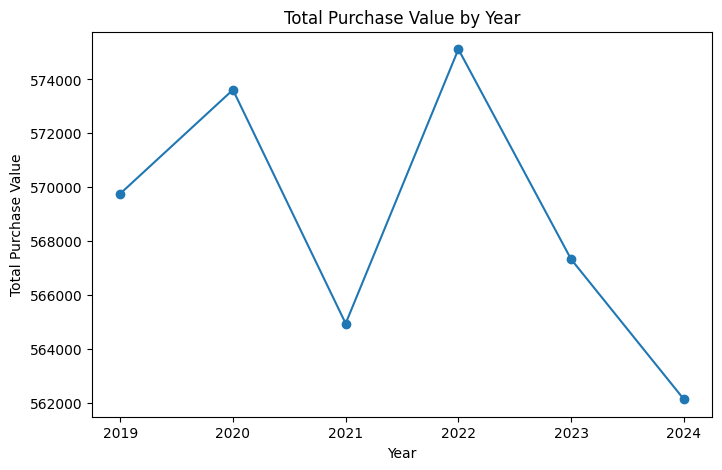

In [30]:
# Convert to datetime
transactions["purchase_date"] = pd.to_datetime(transactions["purchase_date"])

# Extract year
transactions["year"] = transactions["purchase_date"].dt.year

# Aggregate total purchase value per year
yearly_sales = transactions.groupby("year")["purchase_value"].sum()

# Plot
plt.figure(figsize=(8,5))
plt.plot(yearly_sales.index, yearly_sales.values, marker="o")

plt.title("Total Purchase Value by Year")
plt.xlabel("Year")
plt.ylabel("Total Purchase Value")

plt.show()

Q10. Plot purchasing value across product categories.

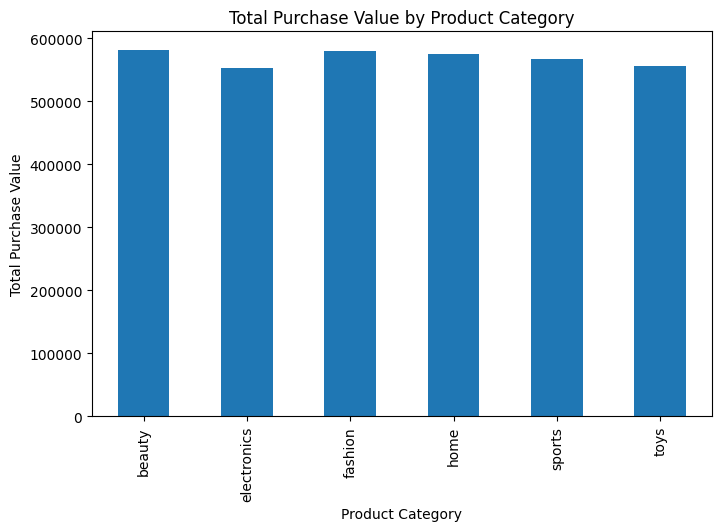

In [35]:
# Aggregate total purchase value per product category
category_sales = transactions.groupby("product_category")["purchase_value"].sum()

# Plot
plt.figure(figsize=(8,5))
category_sales.plot(kind="bar")

plt.title("Total Purchase Value by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Purchase Value")

plt.show()

### Free exercise

Explore the transactions dataset and:

- Create two visualisations of your choice
- Identify three patterns in the data
- Write five insights in plain English explaining what the data tells us

Your insights should focus on behaviour, spending patterns, or conversion

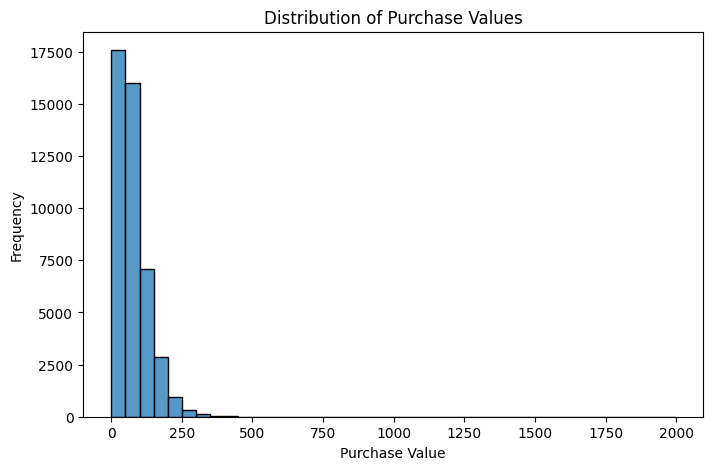

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(transactions["purchase_value"], bins=40)

plt.title("Distribution of Purchase Values")
plt.xlabel("Purchase Value")
plt.ylabel("Frequency")

plt.show()

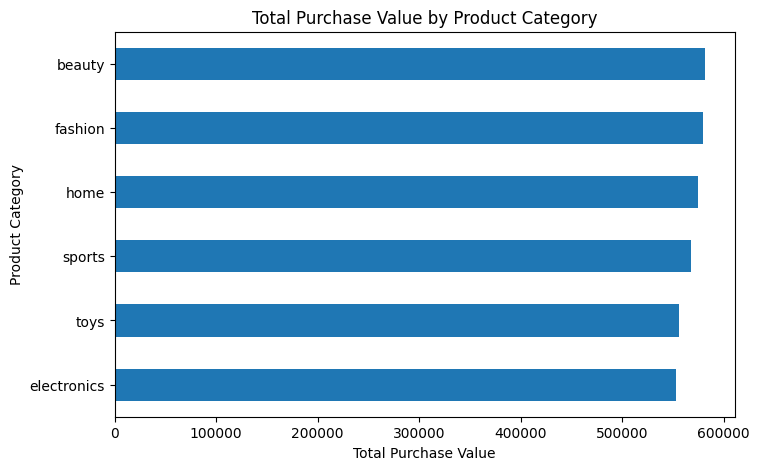

In [37]:
category_sales = transactions.groupby("product_category")["purchase_value"].sum()

plt.figure(figsize=(8,5))
category_sales.sort_values().plot(kind="barh")

plt.title("Total Purchase Value by Product Category")
plt.xlabel("Total Purchase Value")
plt.ylabel("Product Category")

plt.show()

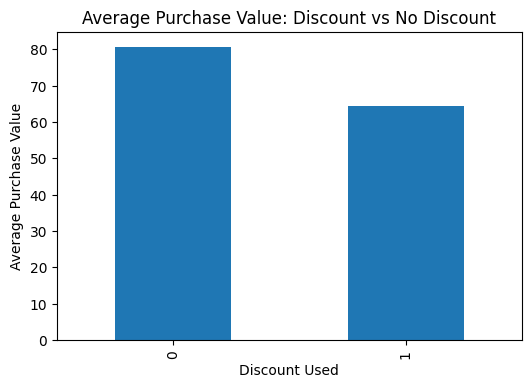

In [40]:
avg_spend = transactions.groupby("discount_used")["purchase_value"].mean()

plt.figure(figsize=(6,4))
avg_spend.plot(kind="bar")

plt.title("Average Purchase Value: Discount vs No Discount")
plt.xlabel("Discount Used")
plt.ylabel("Average Purchase Value")

plt.show()

Pattern 1

Most purchases are relatively low in value, with a small number of very high-value transactions.

Pattern 2

Revenue does not appear strongly concentrated in a single product category.

Pattern 3

Discount usage appears to not influence purchasing behaviour and spending levels.

Insight 1

Spending appears relatively consistent across product categories, suggesting no single category dominates revenue generation.

Insight 2

Discount usage does not significantly alter average purchase value, indicating promotions may influence frequency rather than basket size.

Insight 3

Revenue growth may require focusing on customer acquisition or purchase frequency rather than category prioritisation.

Insight 4

The absence of large category differences suggests pricing and product mix may already be balanced.

Insight 5

Further analysis should explore behavioural drivers (e.g., time on site, traffic source) rather than product-level differences.